In [1]:
# STEP 1: Upload the dataset file into Colab
from google.colab import files
uploaded = files.upload()   # a file picker will pop up — choose spam.csv

Saving spam.csv to spam.csv


In [2]:
# STEP 2: Import libraries
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# STEP 3: Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# The raw Kaggle CSV has some junk columns — clean it up
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Peek at the data
print(df.head())
print(df['label'].value_counts())
print("Total rows:", len(df))

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64
Total rows: 5572


In [4]:
# STEP 4: Encode labels
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

In [5]:
# STEP 5: Text cleaning function
def clean_text(text):
    text = text.lower()                                  # lowercase everything
    text = re.sub(r'\d+', '', text)                       # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()               # remove extra whitespace
    return text

df['clean_message'] = df['message'].apply(clean_text)
print(df[['message', 'clean_message']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  


In [6]:
# STEP 6: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df['clean_message'])
y = df['label_num']

print("Shape of feature matrix:", X.shape)

Shape of feature matrix: (5572, 3000)


In [7]:
# STEP 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [8]:
# STEP 8: Train three different classifiers

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Naive Bayes trained successfully.
Logistic Regression trained successfully.
SVM trained successfully.


In [9]:
# STEP 9: Evaluate all models
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
print(results_df)


--- Naive Bayes ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


--- Logistic Regression ---
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.72      0.83       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


--- SVM ---
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted av

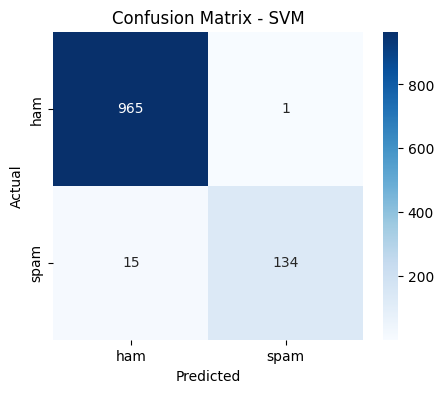

Best performing model: SVM


In [10]:
# STEP 10: Confusion matrix heatmap for the best model (example: SVM)
best_model_name = results_df.sort_values('F1-score', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print("Best performing model:", best_model_name)

In [11]:
# STEP 11: Test with your own example messages
new_messages = [
    "Congratulations! You won a free iPhone, click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been suspended, verify immediately",
    "Can you send me the notes from today's class?"
]

cleaned_new = [clean_text(msg) for msg in new_messages]
new_features = vectorizer.transform(cleaned_new)
predictions = best_model.predict(new_features)

for msg, pred in zip(new_messages, predictions):
    label = "SPAM" if pred == 1 else "HAM (Not Spam)"
    print(f"'{msg}' --> {label}")


'Congratulations! You won a free iPhone, click here to claim now!!!' --> SPAM
'Hey, are we still meeting for lunch tomorrow?' --> HAM (Not Spam)
'URGENT: Your account has been suspended, verify immediately' --> SPAM
'Can you send me the notes from today's class?' --> HAM (Not Spam)


In [12]:
# STEP 12: Save model and vectorizer to disk
import pickle

with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved.")

# If on Colab, download them to your computer:
from google.colab import files
files.download('spam_classifier_model.pkl')
files.download('tfidf_vectorizer.pkl')

Model and vectorizer saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>